

### **Project: Customer Churn Prediction**  

#### **1. Problem Definition**  
- To Predict whether a customer will churn (`Churn` = "Yes"/"No") based on their attributes.    

#### **2. Data Collection & Understanding**  
- Load the dataset using **Pandas**.  
- Check for missing values, duplicates, and data types.  
- Understand feature distributions and relationships with `Churn`.  

#### **3. Data Preprocessing & Feature Engineering**  
- **Handle Missing Values:** Use appropriate imputation strategies.  
- **Convert Categorical Data:** Using Labelencoder to encode categorical variables.  
- **Convert `TotalCharges` to Numeric:** This column might have missing or incorrectly formatted values. Convert it properly.  
- **Feature Scaling:** Normalize numerical features (`MonthlyCharges`, `TotalCharges`, `tenure`) using **MinMaxScaler** or **StandardScaler**.  
- **Feature Selection:** Drop unimportant or highly correlated features to avoid redundancy.  

#### **4. Exploratory Data Analysis (EDA)**  
- **Univariate Analysis:** Distribution of tenure, MonthlyCharges, TotalCharges, etc.  
- **Bivariate Analysis:** How each feature correlates with `Churn`.  
- **Visualizations:**  
  - Countplot for categorical features  
  - Boxplot for numerical features  
  - Heatmap for feature correlations  
- **Class Imbalance Check:** If churn cases are significantly less than non-churn cases, consider balancing techniques like **SMOTE** or **undersampling**.  

#### **5. Model Selection & Training**  
- **Split the Data:** Train-test split (e.g., 80%-20%).  
- **Baseline Model:** Train a simple **Logistic Regression** model for reference.  
- **Try Different Models:**  
  - Logistic Regression  
  - Decision Tree  
  - Random Forest  
  - Gradient Boosting (XGBoost, LightGBM)  
  - Support Vector Machine (SVM)  
  - Neural Network (optional)  
- **Hyperparameter Tuning:** Use **GridSearchCV** or **RandomizedSearchCV** to optimize model performance.  

#### **6. Model Evaluation**  
- Use appropriate evaluation metrics:  
  - **Accuracy** (but not always the best for imbalanced data)  
  - **Precision, Recall, F1-score**  
  - **ROC-AUC Curve**  
  - **Confusion Matrix**  
- Compare model performance and choose the best one.  

#### **7. Feature Importance & Insights**  
- Extract feature importance from models like Random Forest, XGBoost.  
- Interpret business insights from important features affecting churn.  





# **1. Problem Definition**  
- To Predict whether a customer will churn (`Churn` = "Yes"/"No") based on their attributes.  
- Reduce churn by understanding key factors driving customer attrition.  


### Importing dependencies

In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score,recall_score,roc_auc_score,f1_score,classification_report
from sklearn.preprocessing import MinMaxScaler
import joblib


## **2.Data Collection & Understanding**  
- The data is collected from 'https://www.kaggle.com/datasets/blastchar/telco-customer-churn'


In [6]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.drop_duplicates(inplace=True)
pd.set_option("display.max_columns", None)

In [7]:
# Checking for null values
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### **3. Data Preprocessing & Feature Engineering**  


In [9]:
#Getting Info related to the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
#Converting Senior citizen into a object data type
df.SeniorCitizen = df.SeniorCitizen.replace({0:"No",1:"Yes"})
print(df.SeniorCitizen)

0        No
1        No
2        No
3        No
4        No
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: SeniorCitizen, Length: 7043, dtype: object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
#Converting Total Charges Column int numeric 
df.TotalCharges

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: object

In [13]:
## df.TotalCharges = df.TotalCharges.astype(float) gives an error due to some missing value

df[df.TotalCharges== " "]

df.TotalCharges = df.TotalCharges.replace(" ", "0.0")

# Converting total_charges error after making changes to the column 

df.TotalCharges = df.TotalCharges.astype(float)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
# Dropping the customerID column as it has no use in modeling
df.drop('customerID',axis=1,inplace=True)

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
#Making a copy of our original data 
df_copy = df.copy()

Text(0.5, 1.0, 'Total Charges Distribution')

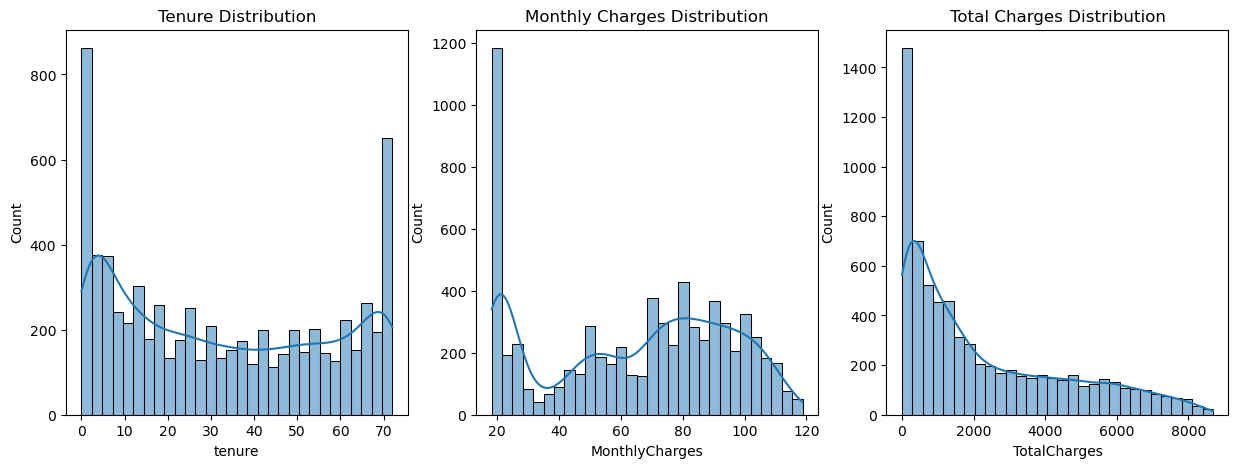

In [18]:
#Normalizing the data to scale the features to a standard scale 

#Checking feature distributions to select a normalizing scale
df_copy

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df_copy["tenure"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Tenure Distribution")

sns.histplot(df_copy["MonthlyCharges"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Monthly Charges Distribution")

sns.histplot(df_copy["TotalCharges"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Total Charges Distribution")

In [19]:
# Since the normalizations are skewed we ll use MinMaxScales from sklearn.preprocessing

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_copy[['tenure',"MonthlyCharges",'TotalCharges']] = scaler.fit_transform(df_copy[['tenure','MonthlyCharges','TotalCharges']])

## Exploratory data analysis

In [21]:
#Grouping category and numerical Features
category_features = {}
numerical_features = {}
for columns in df_copy.columns:
    if pd.api.types.is_numeric_dtype(df[columns]):
        numerical_features[columns] = df[columns].unique()
        
for columns in df_copy.columns:
    if not pd.api.types.is_numeric_dtype(df[columns]):
        category_features[columns] = df[columns].unique()

In [22]:
numerical_features,category_features

({'tenure': array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
         21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
          9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
         36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
         54, 51, 26,  0, 39], dtype=int64),
  'MonthlyCharges': array([29.85, 56.95, 53.85, ..., 63.1 , 44.2 , 78.7 ]),
  'TotalCharges': array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])},
 {'gender': array(['Female', 'Male'], dtype=object),
  'SeniorCitizen': array(['No', 'Yes'], dtype=object),
  'Partner': array(['Yes', 'No'], dtype=object),
  'Dependents': array(['No', 'Yes'], dtype=object),
  'PhoneService': array(['No', 'Yes'], dtype=object),
  'MultipleLines': array(['No phone service', 'No', 'Yes'], dtype=object),
  'InternetService': array(['DSL', 'Fiber optic', 'No'], dtype=object),
  'OnlineSecurity': array(['No', 'Yes', 'No internet service'], d

**Univariate Analysis**

In [24]:


#Looking at distributions of Numerical Features

def plot_histogram(df,columns):
    plt.figure(figsize=(8,5))
    sns.histplot(df[columns],bins=50,kde=True)
    plt.title(f"Distribution of {columns}")

    mean = df[columns].mean(numeric_only= True)
    median = df[columns].median(numeric_only= True)

    plt.axvline(mean, color = 'red',linestyle = '--',label = 'Mean')
    plt.axvline(median, color = 'blue',linestyle = '-',label = 'Median')

    plt.legend()
    plt.show()

    

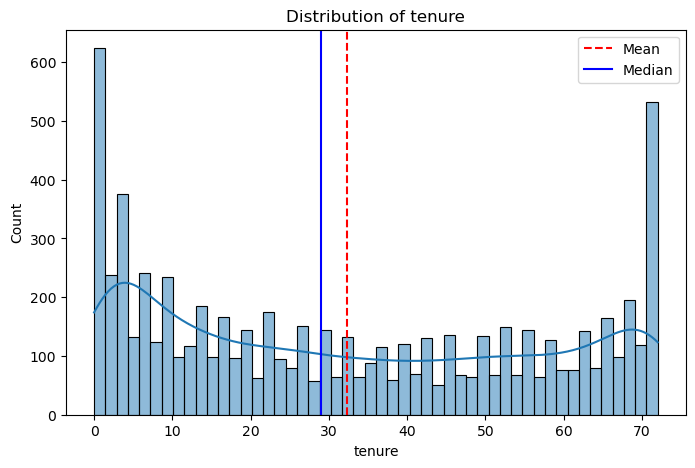

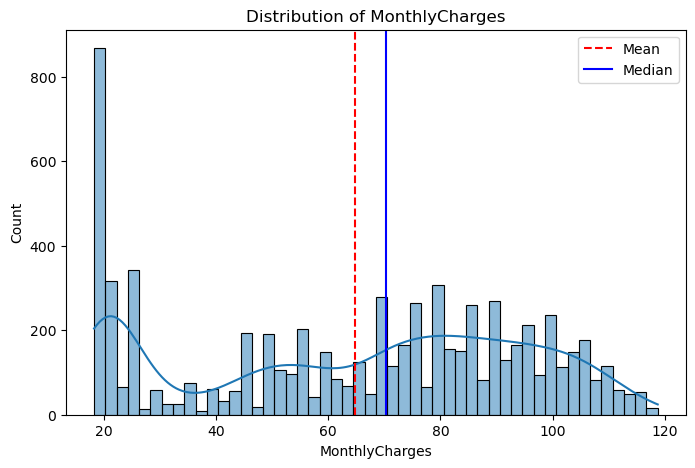

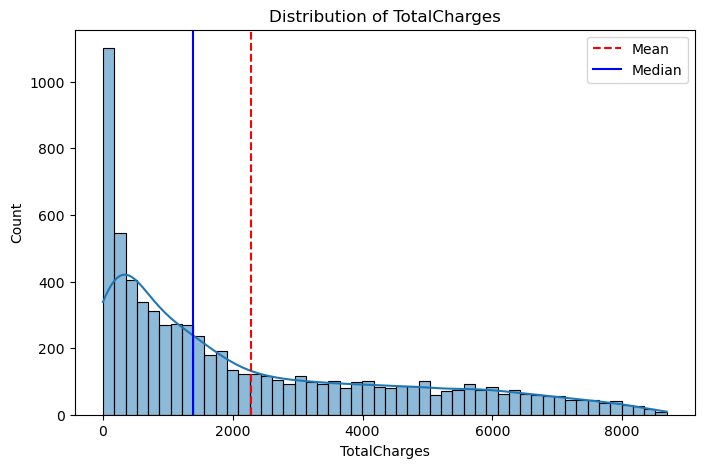

In [25]:
plot_histogram(df,'tenure')
plot_histogram(df,'MonthlyCharges')
plot_histogram(df,'TotalCharges')

 ### **Bivariate Analysis**

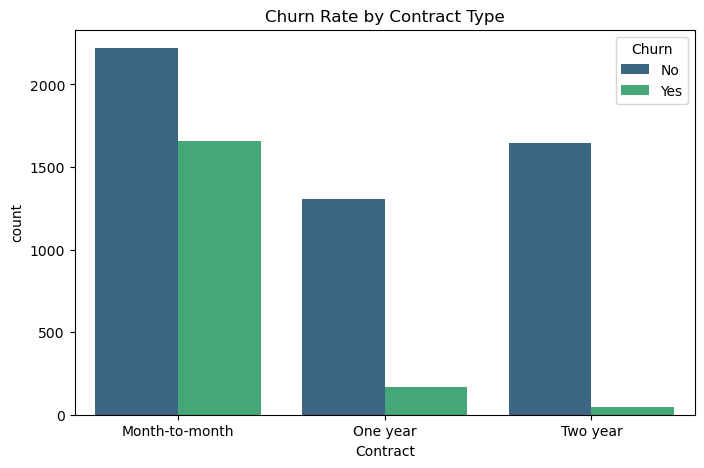

In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Contract", hue="Churn", data=df, palette="viridis")
plt.title("Churn Rate by Contract Type")
plt.show()

#### It is observed that Customer with month to month contract type have higher churn rate

### **Using Chi Square test to if categorical features significant impact on churn**


In [30]:
from scipy.stats import chi2_contingency

In [31]:
category_features

{'gender': array(['Female', 'Male'], dtype=object),
 'SeniorCitizen': array(['No', 'Yes'], dtype=object),
 'Partner': array(['Yes', 'No'], dtype=object),
 'Dependents': array(['No', 'Yes'], dtype=object),
 'PhoneService': array(['No', 'Yes'], dtype=object),
 'MultipleLines': array(['No phone service', 'No', 'Yes'], dtype=object),
 'InternetService': array(['DSL', 'Fiber optic', 'No'], dtype=object),
 'OnlineSecurity': array(['No', 'Yes', 'No internet service'], dtype=object),
 'OnlineBackup': array(['Yes', 'No', 'No internet service'], dtype=object),
 'DeviceProtection': array(['No', 'Yes', 'No internet service'], dtype=object),
 'TechSupport': array(['No', 'Yes', 'No internet service'], dtype=object),
 'StreamingTV': array(['No', 'Yes', 'No internet service'], dtype=object),
 'StreamingMovies': array(['No', 'Yes', 'No internet service'], dtype=object),
 'Contract': array(['Month-to-month', 'One year', 'Two year'], dtype=object),
 'PaperlessBilling': array(['Yes', 'No'], dtype=object),

In [32]:
chi2_values = {}
for features_names,features in category_features.items():
    contingency_table = pd.crosstab(df_copy[features_names],df_copy['Churn'])
    chi2,p , dof, expected = chi2_contingency(contingency_table)
    chi2_values[features_names] = round(p,)

In [33]:
df_copy.MultipleLines.value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

### Numerical Features vs Churn

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


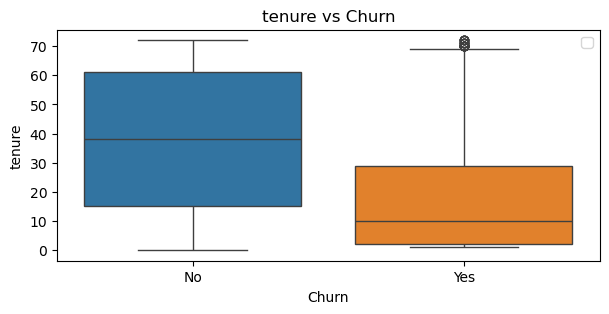

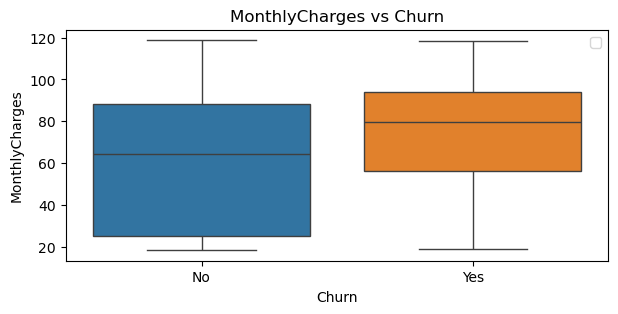

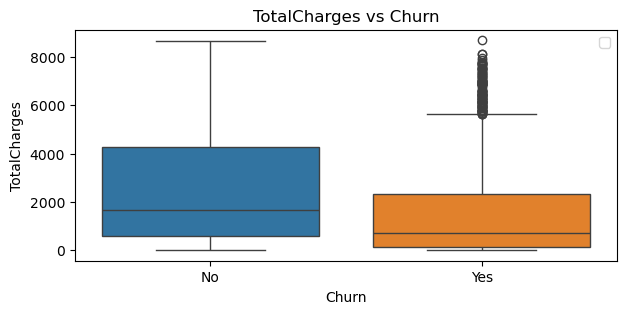

In [35]:
# To check how numerical features effect churn

for col , val in numerical_features.items():
    plt.figure(figsize=(7,3))
    sns.boxplot(x='Churn',y = col,data=df,hue = "Churn")
    plt.title(f"{col} vs Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.legend()

    1.Customer with lower tenure churn the most
    2.Customer with higher monthly charges churn the most

C:\Users\dmmd1\AppData\Local\Temp\ipykernel_14540\1944183029.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy['Churn'] = df_copy["Churn"].replace({"Yes":1,"No":0})


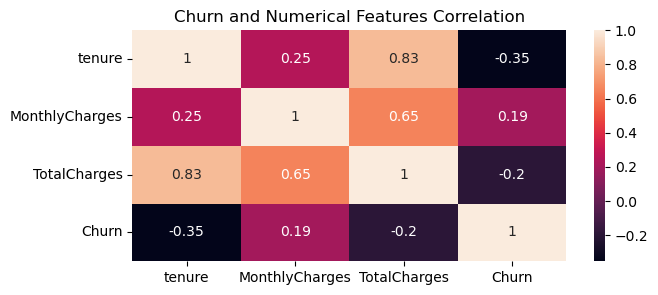

In [37]:
## Creating a heatmap for numerical features
df_copy['Churn'] = df_copy["Churn"].replace({"Yes":1,"No":0})
numerical_features_list = list(numerical_features.keys())
numerical_features_list.append("Churn")
plt.figure(figsize=(7,3))
sns.heatmap(df_copy[numerical_features_list].corr(),annot=True)
plt.title("Churn and Numerical Features Correlation")
plt.show()



### Derived Insights
 1. Tenure is negatively correlated to Churn so it depicts that higher the Tenure lower the Churn risk
 2. Monthly Charges is Positively related to Churn so it depicts that higher the monthly charges higher the churn risk
 3. Total Charges is Negatively related to churn so it depicts that higher the total charges lower the churn risk

## Visualising Our Data 

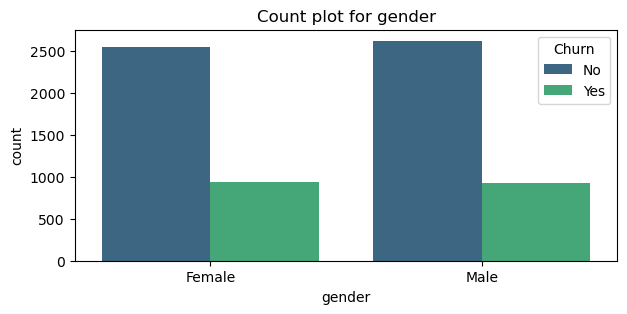

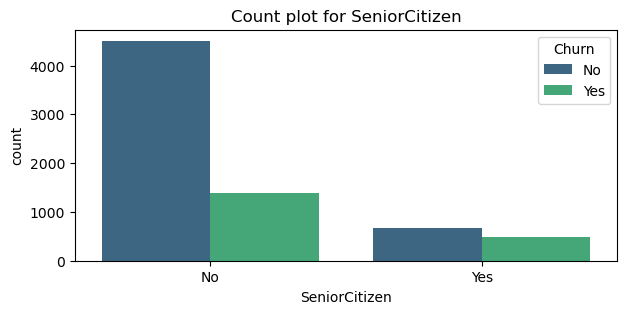

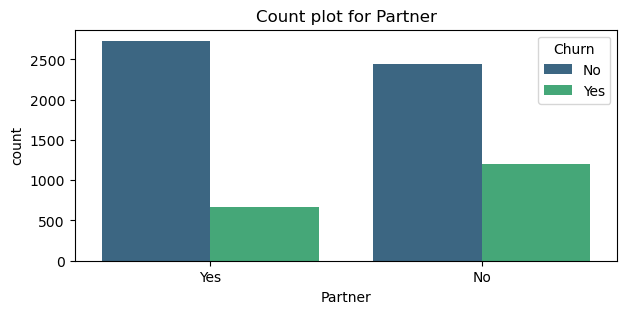

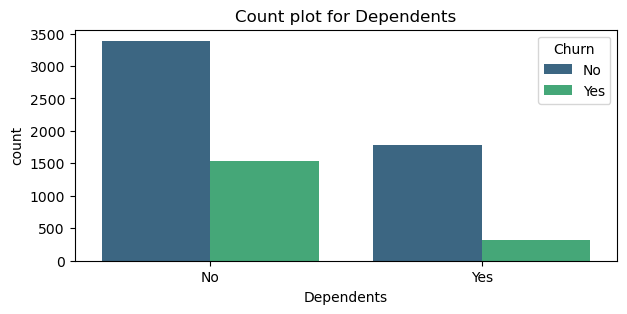

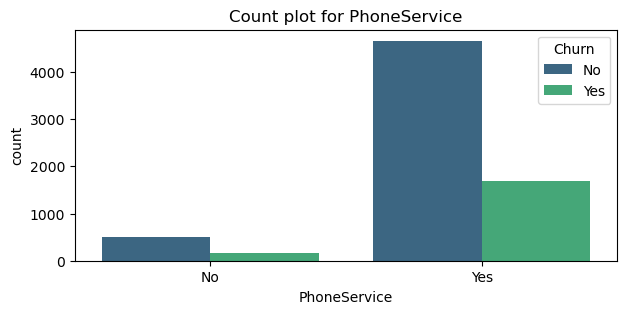

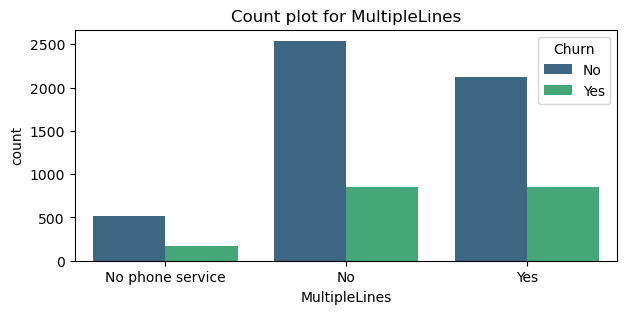

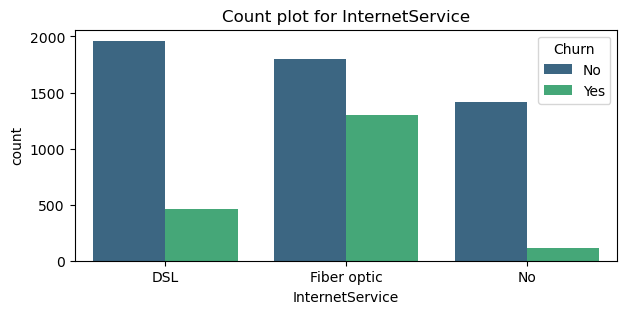

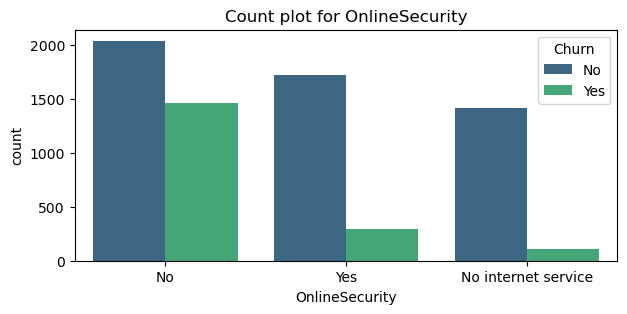

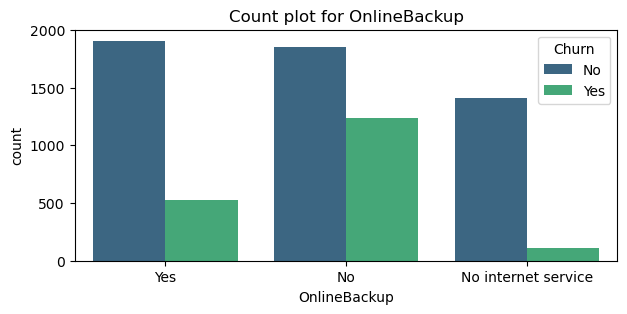

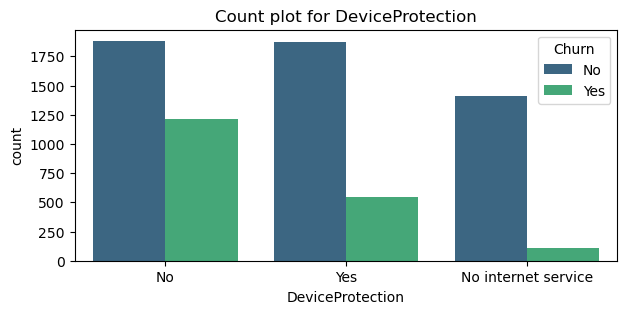

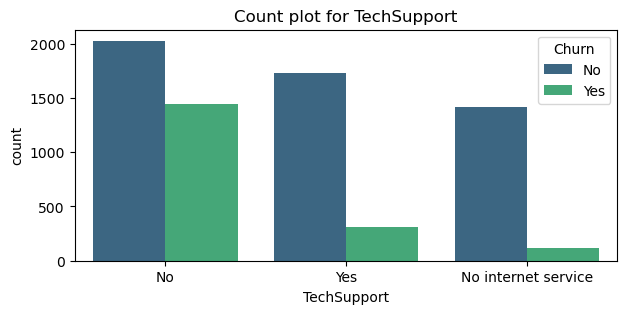

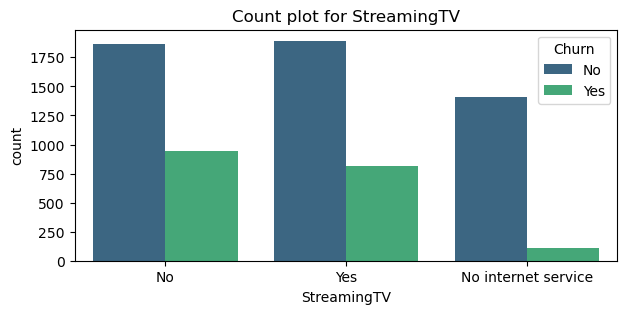

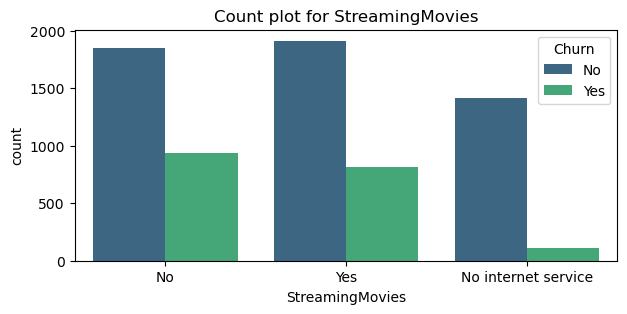

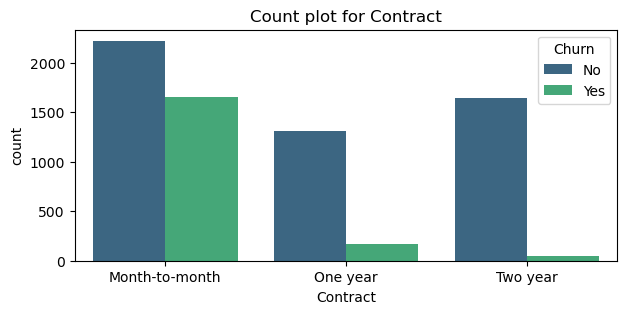

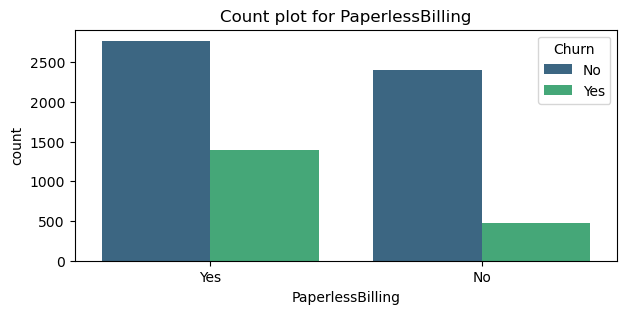

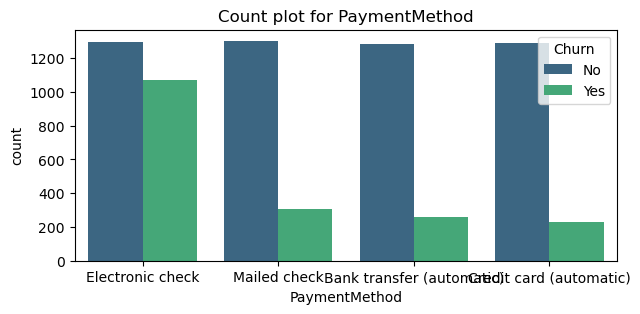

In [40]:
for cols in df.columns:
    if not pd.api.types.is_numeric_dtype(df_copy[cols]):
        plt.figure(figsize=(7,3))
        sns.countplot(x=df[cols],palette="viridis",hue = df.Churn )
        plt.title(f"Count plot for {cols}")
        plt.show()
    

In [41]:
# Making BoxPlot for numerical Features

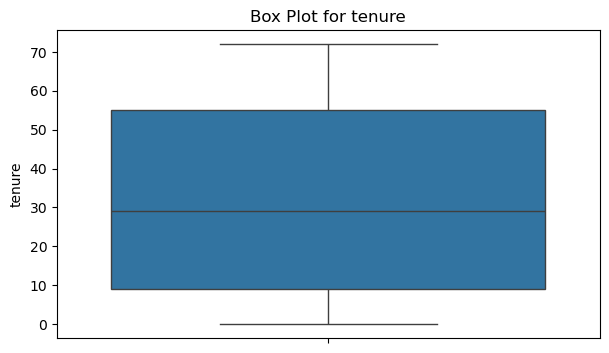

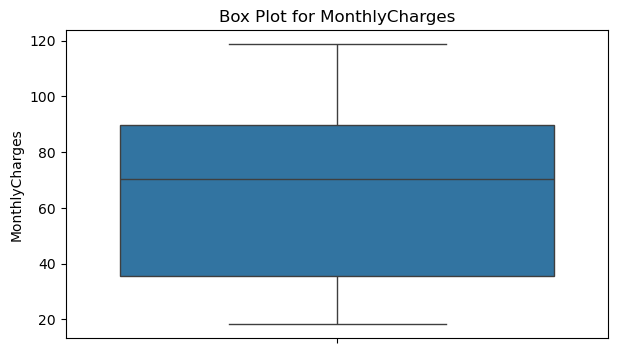

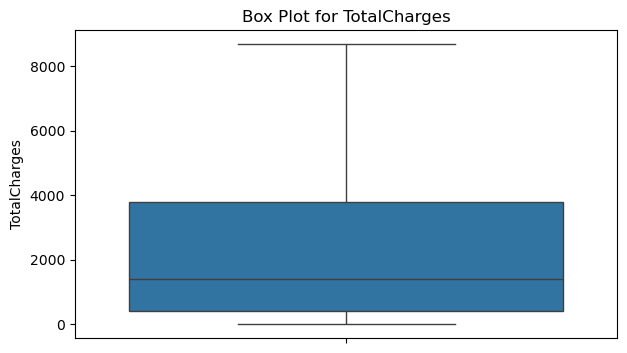

In [42]:
for cols in list(numerical_features.keys()):
    plt.figure(figsize=(7,4))
    sns.boxplot(df[cols])
    plt.title(f"Box Plot for {cols}")
    plt.show()
    
    

## Modeling 

In [44]:
df_copy

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,0.013889,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,0.115423,0.003437,0
1,Male,No,No,No,0.472222,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,0.385075,0.217564,0
2,Male,No,No,No,0.027778,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,0.354229,0.012453,1
3,Male,No,No,No,0.625000,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),0.239303,0.211951,0
4,Female,No,No,No,0.027778,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0.521891,0.017462,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,No,Yes,Yes,0.333333,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,0.662189,0.229194,0
7039,Female,No,Yes,Yes,1.000000,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),0.845274,0.847792,0
7040,Female,No,Yes,Yes,0.152778,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,0.112935,0.039892,0
7041,Male,Yes,Yes,No,0.055556,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,0.558706,0.035303,1


## Label Encoding for Categorical Features

In [46]:
categorical_columns = df_copy.select_dtypes(include="object").columns

In [47]:
categorical_columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [48]:
encoders = {}

for col in categorical_columns:
    label_encoder = LabelEncoder()
    df_copy[col] = label_encoder.fit_transform(df_copy[col])
    encoders[col] = label_encoder

joblib.dump(encoders,'encoders.pkl')

['encoders.pkl']

## Splitting the data and checking for Class imbalance

In [50]:
X = df_copy.drop('Churn',axis=1)
y = df_copy.Churn

In [51]:
Xtrain , Xtest , ytrain , ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [52]:
ytrain.value_counts()

Churn
0    3635
1    1295
Name: count, dtype: int64

In [53]:
smote = SMOTE()

In [54]:
Xtrain_smote , ytrain_smote = smote.fit_resample(Xtrain,ytrain)

### Choosing our data on a baseline model .

In [56]:
# Writing a loop to fit the training data with cross validation on different scoring parameters

models = {
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" :RandomForestClassifier(),
    "XGBoost" : XGBClassifier()
}

scoring_paramters = ["accuracy","f1","recall","roc_auc","precision"]

model_cross_validation_score ={}

for model_name , model in models.items():
    parameter_scores = {}
    for parameter in scoring_paramters:
        scores = cross_val_score(model,Xtrain_smote,ytrain_smote,cv=5,scoring = parameter)
        parameter_scores[parameter + " score" ] = scores.mean()
    model_cross_validation_score[model_name] = parameter_scores
        

In [57]:
model_cross_validation_score

{'Decision Tree': {'accuracy score': 0.7563961485557084,
  'f1 score': 0.7583695214267901,
  'recall score': 0.7623108665749656,
  'roc_auc score': 0.7590393336978671,
  'precision score': 0.7561052738637757},
 'Random Forest': {'accuracy score': 0.8363136176066025,
  'f1 score': 0.8379972847393413,
  'recall score': 0.8646492434662998,
  'roc_auc score': 0.9090598623727363,
  'precision score': 0.8200298123424045},
 'XGBoost': {'accuracy score': 0.8163686382393397,
  'f1 score': 0.8165593726623994,
  'recall score': 0.8376891334250344,
  'roc_auc score': 0.8986814346989475,
  'precision score': 0.8023308972052388}}

# It can be observed that Random Forest gives better score on all of the scoring parameters 
Since our project objective is to predict the customer will churn or not churn and reduce the churn we will hypertune the model and evaluate on different scoring methods


In [59]:
rfc_model = RandomForestClassifier(random_state=42)

rfc_model.fit(Xtrain_smote,ytrain_smote)

baseline_model = rfc_model.score(Xtest,ytest)

baseline_model

0.7652626597255088

In [60]:
# Evaluating our model on different scoring Methods

def fit_score(model,train_setx,train_sety,test_setx,test_sety):
   
    model.fit(train_setx,train_sety)
    y_preds = model.predict(test_setx)
    y_predict_proba = model.predict_proba(test_setx)[:,1]
    
    scores = {}

    scores["Accuracy"] = round(accuracy_score(test_sety,y_preds)*100,2)
    scores["Precision"] = round(precision_score(test_sety,y_preds),2)
    scores["F1_score"] = round(f1_score(test_sety,y_preds),2)
    scores["Recall"] = round(recall_score(test_sety,y_preds),2)
    scores["Roc_Auc"] = round(roc_auc_score(test_sety,y_predict_proba),2)

    print(classification_report(test_sety,y_preds))
    return scores

In [61]:
fit_score(rfc_model,
          train_setx=Xtrain_smote,
          test_setx=Xtest,
          train_sety=ytrain_smote,
          test_sety=ytest)

              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1539
           1       0.56      0.66      0.60       574

    accuracy                           0.77      2113
   macro avg       0.71      0.73      0.72      2113
weighted avg       0.78      0.77      0.77      2113



{'Accuracy': 76.53,
 'Precision': 0.56,
 'F1_score': 0.6,
 'Recall': 0.66,
 'Roc_Auc': 0.83}

`The accuracy of our model to predict customer churn is 77.41%`

`There is a class imbalance in Customer Churn evaluating our model on accuracy alone is no good so the model will be evaluated on roc_auc_score to measure how well the model performs on separating the churn and no churn and f1 score to maintain a balance between %precision and recall `

 ### `Performing Hyper Parameter Tuning to Improve the accuracy of the model `

In [ ]:
from sklearn.model_selection import GridSearchCV

params_list = {
    'n_estimators': [500, 700, 900,1000],
    'max_depth': [5, 10, 15,20],
    'min_samples_split': [2, 5, 10,15,20],
    'min_samples_leaf': [1, 2, 4,6,8]
}

grid_search_model = GridSearchCV(rfc_model, param_grid=params_list,n_jobs=-1,verbose=True,cv=2)
grid_search_model.fit(Xtrain_smote,ytrain_smote)


In [126]:
grid_search_model.best_params_

{'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 1000}

In [148]:
grid_search_rfc = RandomForestClassifier(max_depth=20,min_samples_leaf=1,min_samples_split=2,n_estimators=10000,random_state=42 )


KeyboardInterrupt



In [ ]:
fit_score(grid_search_rfc,
          train_setx=Xtrain_smote,
          test_setx=Xtest,
          train_sety=ytrain_smote,
          test_sety=ytest)